In [1]:
# Ячейка 1: Импорты и загрузка данных
import numpy as np
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Загружаем подготовленные признаки
data = np.load('prepared_data_convnext.npz', allow_pickle=True)
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']

# Загружаем маппинг классов
with open('class_mapping_convnext.pkl', 'rb') as f:
    mapping = pickle.load(f)
label_to_idx = mapping['label_to_idx']
idx_to_label = mapping['idx_to_label']

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")

Train shape: (468, 2304), Val shape: (117, 2304)


Запуск кросс-валидации для поиска оптимального Kernel SVM...
Fitting 5 folds for each of 28 candidates, totalling 140 fits



Параметры лучшей модели: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}
Лучший результат на кросс-валидации (CV Accuracy): 0.8184

Качество оптимизированной модели на валидационной выборке: 0.8376

Отчет о классификации:
              precision    recall  f1-score   support

    inaction       0.92      0.63      0.75        19
        move       0.79      0.73      0.76        30
        work       0.84      0.94      0.89        68

    accuracy                           0.84       117
   macro avg       0.85      0.77      0.80       117
weighted avg       0.84      0.84      0.83       117



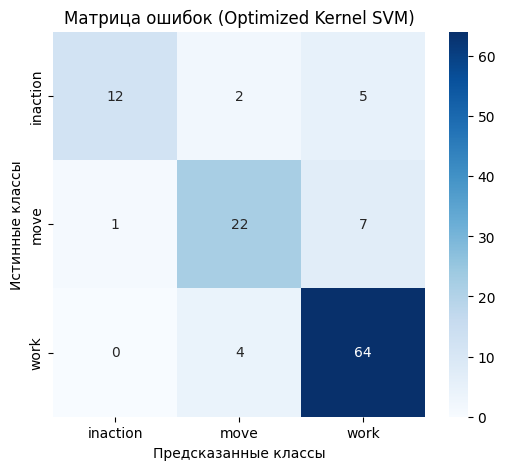

In [5]:
# Ячейки 2 и 3
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# 1. Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 2. Настройка сетки параметров для Kernel SVM
# C контролирует штраф за ошибки, gamma — гибкость разделяющей границы
param_grid = {
    'C': [0.01, 0.1, 1, 5, 10, 15, 20],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf']
}

print("Запуск кросс-валидации для поиска оптимального Kernel SVM...")
# Инициализируем поиск по сетке с кросс-валидацией по 5 фолдам
grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Обучаем сетку на тренировочных данных
grid_search.fit(X_train_scaled, y_train)

# Извлекаем лучшую модель
clf = grid_search.best_estimator_

print("\nПараметры лучшей модели:", grid_search.best_params_)
print(f"Лучший результат на кросс-валидации (CV Accuracy): {grid_search.best_score_:.4f}")

# 3. Оценка качества на отложенной валидационной выборке
y_pred = clf.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_pred)

print("\n" + "="*50)
print(f"Качество оптимизированной модели на валидационной выборке: {val_accuracy:.4f}")
print("="*50)

print("\nОтчет о классификации:")
print(classification_report(y_val, y_pred, target_names=list(mapping['label_to_idx'].keys())))

# Отрисовка матрицы ошибок
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(mapping['label_to_idx'].keys()),
            yticklabels=list(mapping['label_to_idx'].keys()))
plt.title('Матрица ошибок (Optimized Kernel SVM)')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.show()

In [ ]:
# Ячейка 4: Сохранение модели и скейлера для инференса
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(clf, 'classifier.pkl')
print("Модель и scaler сохранены.")

Модель и scaler сохранены.
